In [ ]:
import numpy as np
import cv2
import os
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import euclidean_distances

from google.colab import files
import zipfile
import shutil

In [ ]:
print("Upload ORL dataset zip")

uploaded = files.upload()

zip_name = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_name, 'r') as zip_ref:
    zip_ref.extractall("/content")

print("Dataset extracted")

Upload ORL dataset zip


Saving archive.zip to archive.zip
Dataset extracted


In [ ]:
!find /content -type d -name "orl_faces"
DATASET_PATH = "/content/orl_faces_dataset/orl_faces"

print("Folders:", os.listdir(DATASET_PATH)[:5])

/content/orl_faces_dataset/orl_faces
Folders: ['s14', 's5', 's6', 's20', 's30']


In [ ]:
def load_dataset(path, img_size=(100,100)):

    X = []
    y = []
    labels = {}

    for label, person in enumerate(sorted(os.listdir(path))):

        person_path = os.path.join(path, person)
        labels[label] = person

        for img_name in sorted(os.listdir(person_path)):

            img_path = os.path.join(person_path, img_name)

            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

            if img is None:
                continue

            img = cv2.resize(img, img_size)

            X.append(img.flatten())
            y.append(label)

    return np.array(X), np.array(y), labels

In [ ]:
X, y, label_names = load_dataset(DATASET_PATH)

print("Total images:", X.shape[0])
print("Feature dimension:", X.shape[1])
print("Number of people:", len(label_names))

Total images: 398
Feature dimension: 10000
Number of people: 41


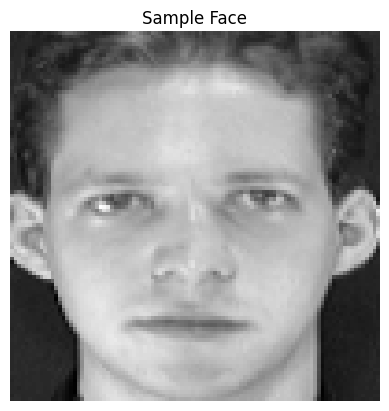

In [ ]:
plt.imshow(X[0].reshape(100,100), cmap='gray')
plt.title("Sample Face")
plt.axis("off")
plt.show()

In [ ]:
X_train = []
X_test = []
y_train = []
y_test = []

for person in np.unique(y):

    idx = np.where(y == person)[0]

    train_idx = idx[:7]
    test_idx = idx[7:]

    for i in train_idx:
        X_train.append(X[i])
        y_train.append(y[i])

    for i in test_idx:
        X_test.append(X[i])
        y_test.append(y[i])

X_train = np.array(X_train)
X_test = np.array(X_test)
y_train = np.array(y_train)
y_test = np.array(y_test)

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
import time
import pandas as pd

components_list = [10,20,50,100,150,200]

results = []

print("Evaluating different PCA components...\n")

for M in components_list:

    start_train = time.time()

    pca_test = PCA(n_components=M)

    X_train_pca_temp = pca_test.fit_transform(X_train)
    X_test_pca_temp = pca_test.transform(X_test)

    train_time = time.time() - start_train


    start_test = time.time()

    correct = 0

    for i in range(len(X_test_pca_temp)):

        distances = euclidean_distances(
            X_test_pca_temp[i].reshape(1,-1),
            X_train_pca_temp
        )

        idx = np.argmin(distances)

        pred = y_train[idx]

        if pred == y_test[i]:
            correct += 1

    accuracy = correct / len(X_test_pca_temp)

    test_time = time.time() - start_test

    results.append([M, accuracy, train_time, test_time])

    print(f"M={M:3d} | Accuracy={accuracy:.4f} | TrainTime={train_time:.4f}s | TestTime={test_time:.4f}s")

results_df = pd.DataFrame(
    results,
    columns=["Components","Accuracy","Train Time","Test Time"]
)

results_df
svd_results = []

print("Evaluating SVD components...\n")

for M in components_list:

    start_train = time.time()

    # SVD decomposition
    U, S, Vt = np.linalg.svd(X_train, full_matrices=False)

    # chọn M components
    Vt_M = Vt[:M]

    # project data
    X_train_svd = np.dot(X_train, Vt_M.T)
    X_test_svd = np.dot(X_test, Vt_M.T)

    train_time = time.time() - start_train


    start_test = time.time()

    correct = 0

    for i in range(len(X_test_svd)):

        distances = euclidean_distances(
            X_test_svd[i].reshape(1,-1),
            X_train_svd
        )

        idx = np.argmin(distances)

        pred = y_train[idx]

        if pred == y_test[i]:
            correct += 1

    accuracy = correct / len(X_test_svd)

    test_time = time.time() - start_test

    svd_results.append([M, accuracy, train_time, test_time])

    print(f"SVD M={M:3d} | Accuracy={accuracy:.4f} | TrainTime={train_time:.4f}s | TestTime={test_time:.4f}s")
svd_df = pd.DataFrame(
    svd_results,
    columns=["Components","Accuracy","Train Time","Test Time"]
)

svd_df

Evaluating different PCA components...

M= 10 | Accuracy=0.9237 | TrainTime=0.3033s | TestTime=0.0500s
M= 20 | Accuracy=0.9576 | TrainTime=0.4030s | TestTime=0.0494s
M= 50 | Accuracy=0.9661 | TrainTime=0.6775s | TestTime=0.1214s
M=100 | Accuracy=0.9576 | TrainTime=2.4956s | TestTime=0.1426s
M=150 | Accuracy=0.9576 | TrainTime=2.6707s | TestTime=0.1879s
M=200 | Accuracy=0.9492 | TrainTime=1.9201s | TestTime=0.0689s
Evaluating SVD components...

SVD M= 10 | Accuracy=0.9237 | TrainTime=0.6861s | TestTime=0.0491s
SVD M= 20 | Accuracy=0.9576 | TrainTime=0.6913s | TestTime=0.0449s
SVD M= 50 | Accuracy=0.9661 | TrainTime=0.6570s | TestTime=0.0467s
SVD M=100 | Accuracy=0.9492 | TrainTime=0.6838s | TestTime=0.0534s
SVD M=150 | Accuracy=0.9576 | TrainTime=0.6896s | TestTime=0.0552s
SVD M=200 | Accuracy=0.9492 | TrainTime=0.6659s | TestTime=0.0686s


,Components,Accuracy,Train Time,Test Time
0,10,0.923729,0.686053,0.049053
1,20,0.957627,0.691283,0.044942
2,50,0.966102,0.656995,0.046730
3,100,0.949153,0.683757,0.053429
4,150,0.957627,0.689623,0.055232
5,200,0.949153,0.665910,0.068604


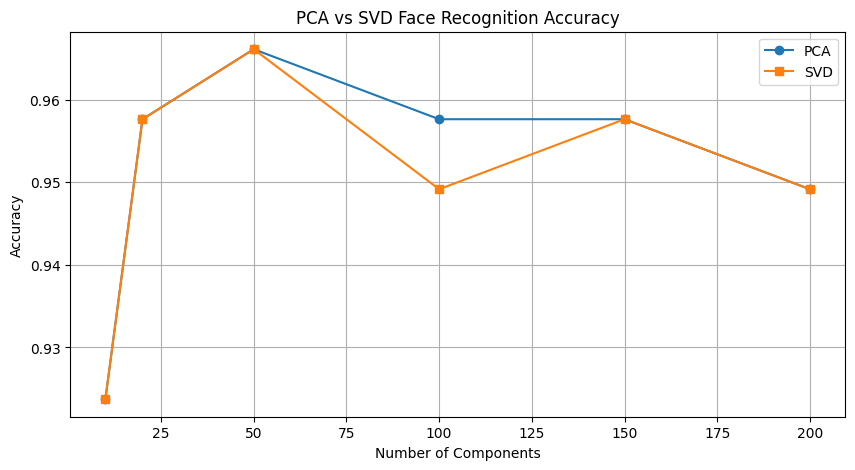

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(results_df["Components"], results_df["Accuracy"], marker='o', label="PCA")
plt.plot(svd_df["Components"], svd_df["Accuracy"], marker='s', label="SVD")

plt.xlabel("Number of Components")
plt.ylabel("Accuracy")
plt.title("PCA vs SVD Face Recognition Accuracy")
plt.legend()
plt.grid()

plt.show()

In [ ]:
best_row = results_df.loc[results_df["Accuracy"].idxmax()]

best_M = int(best_row["Components"])

print("Best PCA Components:", best_M)
print("Best Accuracy:", best_row["Accuracy"])
print("Train Time:", best_row["Train Time"])
print("Test Time:", best_row["Test Time"])

Best PCA Components: 50
Best Accuracy: 0.9661016949152542
Train Time: 0.6775455474853516
Test Time: 0.12136101722717285


In [ ]:
pca = PCA(n_components=best_M)

X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

print("Before PCA:", X_train.shape)
print("After PCA:", X_train_pca.shape)

Before PCA: (280, 10000)
After PCA: (280, 50)


Confusion Matrix:
[[3 0 0 ... 0 0 0]
 [0 3 0 ... 0 0 0]
 [0 0 3 ... 0 0 0]
 ...
 [0 0 0 ... 3 0 0]
 [0 0 0 ... 0 3 0]
 [0 0 0 ... 0 0 3]]


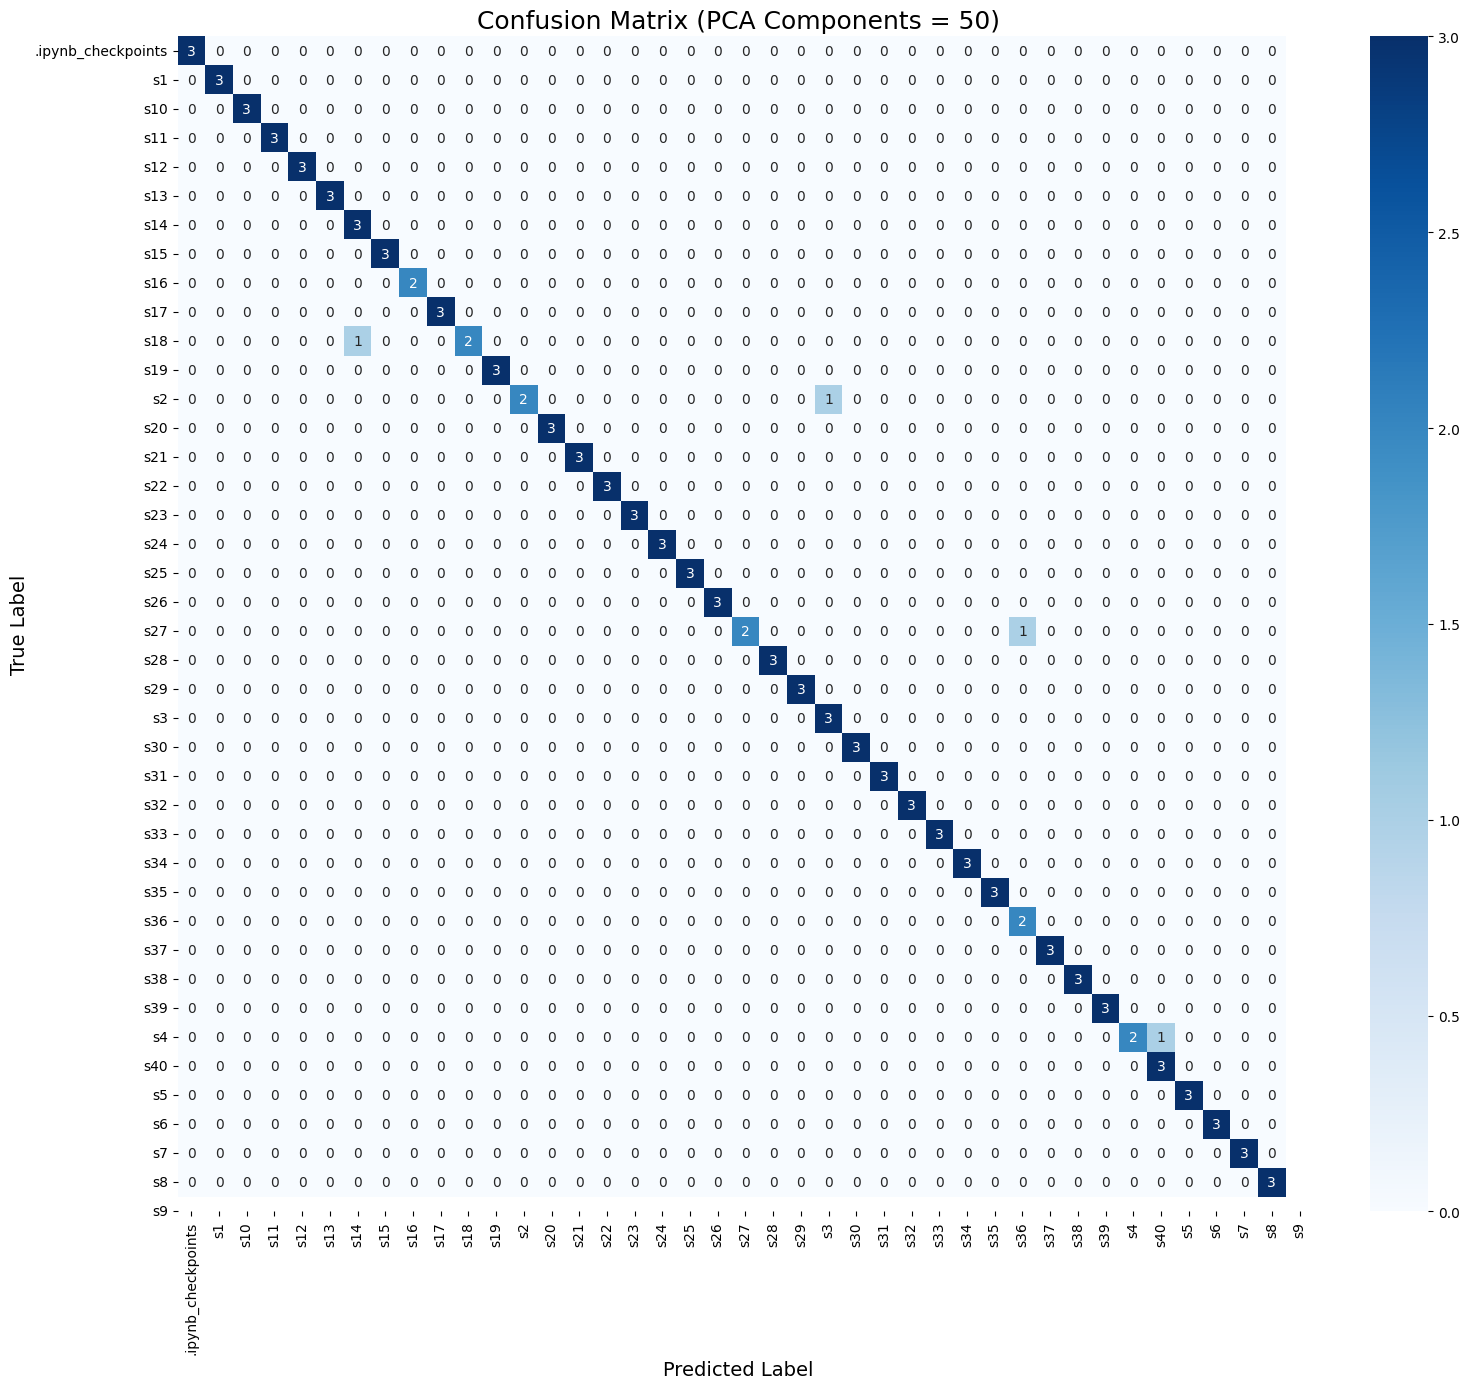

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns

y_pred = []

for i in range(len(X_test_pca)):

    distances = euclidean_distances(
        X_test_pca[i].reshape(1,-1),
        X_train_pca
    )

    idx = np.argmin(distances)

    pred = y_train[idx]

    y_pred.append(pred)

y_pred = np.array(y_pred)

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

labels = [label_names[i] for i in sorted(label_names.keys())]

plt.figure(figsize=(16,14))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels,
    cbar=True
)

plt.title(f"Confusion Matrix (PCA Components = {best_M})", fontsize=18)

plt.xlabel("Predicted Label", fontsize=14)
plt.ylabel("True Label", fontsize=14)

plt.xticks(rotation=90, fontsize=10)
plt.yticks(rotation=0, fontsize=10)

plt.tight_layout()

plt.show()

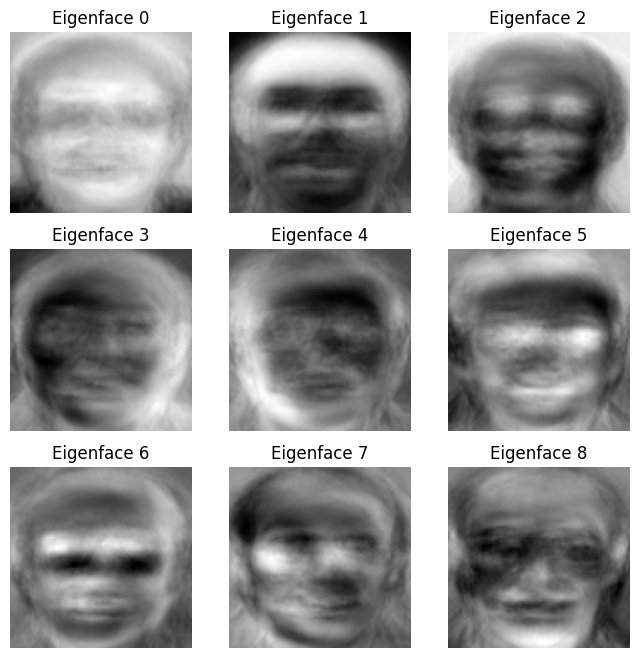

In [ ]:
plt.figure(figsize=(8,8))

for i in range(9):

    plt.subplot(3,3,i+1)

    plt.imshow(pca.components_[i].reshape(100,100), cmap='gray')

    plt.title(f"Eigenface {i}")

    plt.axis("off")

plt.show()

In [ ]:
def predict_face_distance(img):

    img = cv2.resize(img,(100,100))

    img_flat = img.flatten().reshape(1,-1)

    img_flat = scaler.transform(img_flat)

    img_pca = pca.transform(img_flat)

    distances = euclidean_distances(img_pca, X_train_pca)

    min_dist = np.min(distances)

    idx = np.argmin(distances)

    label = y_train[idx]

    return label, min_dist

In [ ]:
correct = 0

for i in range(len(X_test_pca)):

    distances = euclidean_distances(
        X_test_pca[i].reshape(1,-1),
        X_train_pca
    )

    idx = np.argmin(distances)

    pred = y_train[idx]

    if pred == y_test[i]:
        correct += 1

accuracy = correct / len(X_test)

print("Recognition Accuracy:", accuracy)

Recognition Accuracy: 0.9661016949152542


In [ ]:
os.makedirs("unknown_faces", exist_ok=True)

print("Upload unknown faces")

uploaded = files.upload()

for filename in uploaded.keys():

    shutil.move(filename, os.path.join("unknown_faces", filename))

Upload unknown faces


Saving u1.jpg to u1.jpg
Saving u2.jpg to u2 (1).jpg
Saving u3.jpg to u3.jpg
Saving u4.jpg to u4.jpg
Saving u5.jpg to u5.jpg
Saving u6.jpg to u6.jpg
Saving u7.jpg to u7.jpg
Saving u8.jpg to u8.jpg
Saving u9.jpg to u9.jpg
Saving u10.jpg to u10.jpg
Saving u11.jpg to u11.jpg
Saving u12.jpg to u12.jpg
Saving u13.jpg to u13.jpg
Saving u14.jpg to u14.jpg
Saving u15.jpg to u15.jpg
Saving u16.jpg to u16.jpg
Saving u17.jpg to u17.jpg
Saving u18.jpg to u18.jpg
Saving u19.jpg to u19.jpg
Saving u20.jpg to u20.jpg


In [ ]:
distance_list = []
label_list = []
for i in range(len(X_test_pca)):

    distances = euclidean_distances(
        X_test_pca[i].reshape(1,-1),
        X_train_pca
    )

    min_dist = np.min(distances)

    distance_list.append(min_dist)
    label_list.append("known")
unknown_path = "unknown_faces"

for file in os.listdir(unknown_path):

    img_path = os.path.join(unknown_path, file)

    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

    img = cv2.resize(img,(100,100))

    img_flat = img.flatten().reshape(1,-1)

    img_flat = scaler.transform(img_flat)

    img_pca = pca.transform(img_flat)

    distances = euclidean_distances(img_pca, X_train_pca)

    min_dist = np.min(distances)

    distance_list.append(min_dist)
    label_list.append("unknown")

In [ ]:
known_dist = []
unknown_dist = []

for dist,label in zip(distance_list,label_list):

    if label == "known":
        known_dist.append(dist)
    else:
        unknown_dist.append(dist)

print("Known range:", min(known_dist), "-", max(known_dist))
print("Unknown range:", min(unknown_dist), "-", max(unknown_dist))

Known range: 14.517935109816296 - 76.47478177476624
Unknown range: 78.22776246091091 - 253.22840382913995


In [ ]:
thresholds = np.arange(
    min(distance_list),
    max(distance_list),
    10
)

acc_list = []

best_threshold = 0
best_acc = 0

for t in thresholds:

    correct = 0

    for dist,label in zip(distance_list,label_list):

        if dist <= t:
            pred = "known"
        else:
            pred = "unknown"

        if pred == label:
            correct += 1

    acc = correct / len(label_list)

    acc_list.append(acc)

    print("Threshold:",t,"Accuracy:",acc)

    if acc > best_acc:
        best_acc = acc
        best_threshold = t

print("\nBest Threshold:",best_threshold)
print("Best Accuracy:",best_acc)

Threshold: 14.517935109816296 Accuracy: 0.15827338129496402
Threshold: 24.517935109816296 Accuracy: 0.2446043165467626
Threshold: 34.51793510981629 Accuracy: 0.460431654676259
Threshold: 44.51793510981629 Accuracy: 0.6762589928057554
Threshold: 54.51793510981629 Accuracy: 0.8345323741007195
Threshold: 64.51793510981629 Accuracy: 0.9136690647482014
Threshold: 74.51793510981629 Accuracy: 0.9856115107913669
Threshold: 84.51793510981629 Accuracy: 0.9856115107913669
Threshold: 94.51793510981629 Accuracy: 0.9856115107913669
Threshold: 104.51793510981629 Accuracy: 0.9784172661870504
Threshold: 114.51793510981629 Accuracy: 0.9712230215827338
Threshold: 124.51793510981629 Accuracy: 0.9712230215827338
Threshold: 134.5179351098163 Accuracy: 0.9640287769784173
Threshold: 144.5179351098163 Accuracy: 0.9568345323741008
Threshold: 154.5179351098163 Accuracy: 0.9496402877697842
Threshold: 164.5179351098163 Accuracy: 0.9424460431654677
Threshold: 174.5179351098163 Accuracy: 0.935251798561151
Threshold:

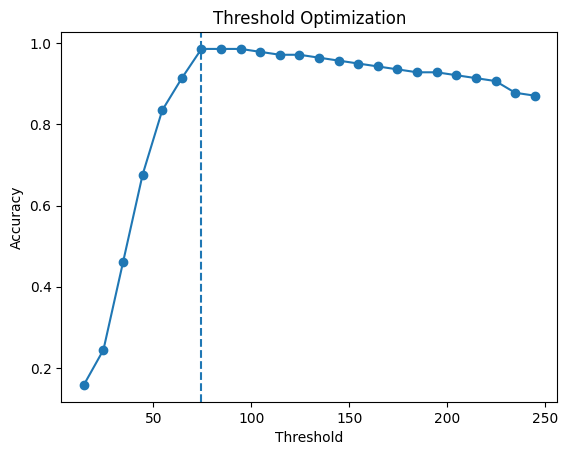

In [ ]:
plt.plot(thresholds, acc_list, marker='o')

plt.axvline(best_threshold, linestyle='--')

plt.xlabel("Threshold")

plt.ylabel("Accuracy")

plt.title("Threshold Optimization")

plt.show()

Saving trungtest.jpg to trungtest (2).jpg
Prediction: Unknown


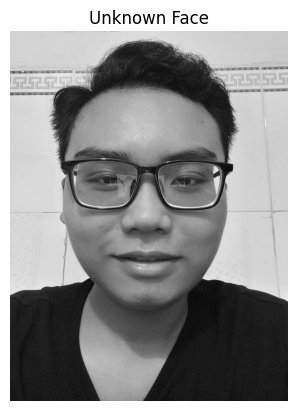

In [ ]:
def predict_uploaded_image(threshold):

    uploaded = files.upload()

    for filename in uploaded.keys():

        img = cv2.imread(filename,cv2.IMREAD_GRAYSCALE)

        label,dist = predict_face_distance(img)

        plt.imshow(img,cmap='gray')
        plt.axis("off")

        if dist > threshold:

            print("Prediction: Unknown")

            plt.title("Unknown Face")

        else:

            print("Prediction:",label_names[label])

            plt.title(label_names[label])

        plt.show()
predict_uploaded_image(best_threshold)

In [ ]:
def register_new_face(person_name):

    print(f"Upload 10 images for {person_name}")

    uploaded = files.upload()

    if len(uploaded) < 10:
        print("Please upload at least 10 images")
        return

    person_path = os.path.join(DATASET_PATH, person_name)

    os.makedirs(person_path, exist_ok=True)

    count = 1

    for filename in uploaded.keys():

        img = cv2.imread(filename, cv2.IMREAD_GRAYSCALE)

        img = cv2.resize(img,(100,100))

        save_path = os.path.join(person_path, f"{count}.jpg")

        cv2.imwrite(save_path, img)

        count += 1

    print(f"{person_name} registered successfully!")

In [ ]:
def retrain_model():

    global X_train, X_test, y_train, y_test
    global scaler, pca
    global X_train_pca, X_test_pca
    global label_names

    print("Reloading dataset...")

    X, y, label_names = load_dataset(DATASET_PATH)

    X_train = []
    X_test = []
    y_train = []
    y_test = []

    for person in np.unique(y):

        idx = np.where(y == person)[0]

        train_idx = idx[:7]
        test_idx = idx[7:]

        for i in train_idx:
            X_train.append(X[i])
            y_train.append(y[i])

        for i in test_idx:
            X_test.append(X[i])
            y_test.append(y[i])

    X_train = np.array(X_train)
    X_test = np.array(X_test)

    y_train = np.array(y_train)
    y_test = np.array(y_test)

    scaler = StandardScaler()

    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    pca = PCA(n_components=best_M)

    X_train_pca = pca.fit_transform(X_train)
    X_test_pca = pca.transform(X_test)

    print("Model retrained successfully")

In [ ]:
import gradio as gr


def demo_predict(file):

    img = cv2.imread(file.name, cv2.IMREAD_GRAYSCALE)

    if img is None:
        return "Cannot read image", None, None

    label, dist = predict_face_distance(img)

    input_img = img

    if dist > best_threshold:

        result = f"Unknown Face (distance={dist:.2f})"
        predicted_img = None

    else:

        person_name = label_names[label]

        result = f"Predicted: {person_name} (distance={dist:.2f})"

        person_folder = os.path.join(DATASET_PATH, person_name)

        sample_img_name = os.listdir(person_folder)[0]

        sample_img_path = os.path.join(person_folder, sample_img_name)

        predicted_img = cv2.imread(sample_img_path, cv2.IMREAD_GRAYSCALE)

    return result, input_img, predicted_img



def register_new_person(name, files):

    if name.strip() == "":
        return "Please enter a name"

    if len(files) < 10:
        return "Please upload at least 10 images"

    person_path = os.path.join(DATASET_PATH, name)

    os.makedirs(person_path, exist_ok=True)

    for i, file in enumerate(files):

        img = cv2.imread(file.name, cv2.IMREAD_GRAYSCALE)

        if img is None:
            continue

        img = cv2.resize(img,(100,100))

        save_path = os.path.join(person_path, f"{i+1}.jpg")

        cv2.imwrite(save_path, img)

    retrain_model()

    return f"{name} registered successfully and model updated!"



with gr.Blocks() as demo:

    gr.Markdown("# Face Recognition System (PCA Eigenfaces)")

    with gr.Tab("Predict Face"):

        file_input = gr.File(label="Upload Face Image")

        result = gr.Textbox(label="Prediction")

        input_img = gr.Image(label="Uploaded Image")

        predicted_img = gr.Image(label="Matched Person")

        btn = gr.Button("Predict")

        btn.click(
            demo_predict,
            inputs=file_input,
            outputs=[result, input_img, predicted_img]
        )


    with gr.Tab("Register New Face"):

        name_input = gr.Textbox(label="Person Name")

        images_input = gr.File(
            file_count="multiple",
            label="Upload 10 Face Images"
        )

        register_btn = gr.Button("Register")

        register_result = gr.Textbox(label="Status")

        register_btn.click(
            register_new_person,
            inputs=[name_input, images_input],
            outputs=register_result
        )


demo.launch(debug=True)

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://49e54f14a5e5dba57e.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Reloading dataset...
Model retrained successfully
Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://49e54f14a5e5dba57e.gradio.live
